# 시계열 데이터 예측 기본 알고리즘

**목표**: 시계열 데이터의 특성을 이해하고, 예측의 기본 알고리즘을 직접 실행해봅니다.

**데이터**: 비트코인 시세 (2019~2024)

**실습 순서**:
1. 데이터 로드
2. 시계열 데이터 탐색 (EDA)
3. 시계열 분해 (Decomposition)
4. 예측 알고리즘 (Moving Average, Exponential Smoothing, ARIMA)
5. 이상탐지 기초 (Z-score, IQR)
6. 정리 & 토론


---
## 1. 데이터 로드

필요한 라이브러리를 설치하고, 비트코인 데이터를 불러옵니다.


[*********************100%***********************]  1 of 1 completed

Data Shape: (1826, 1)


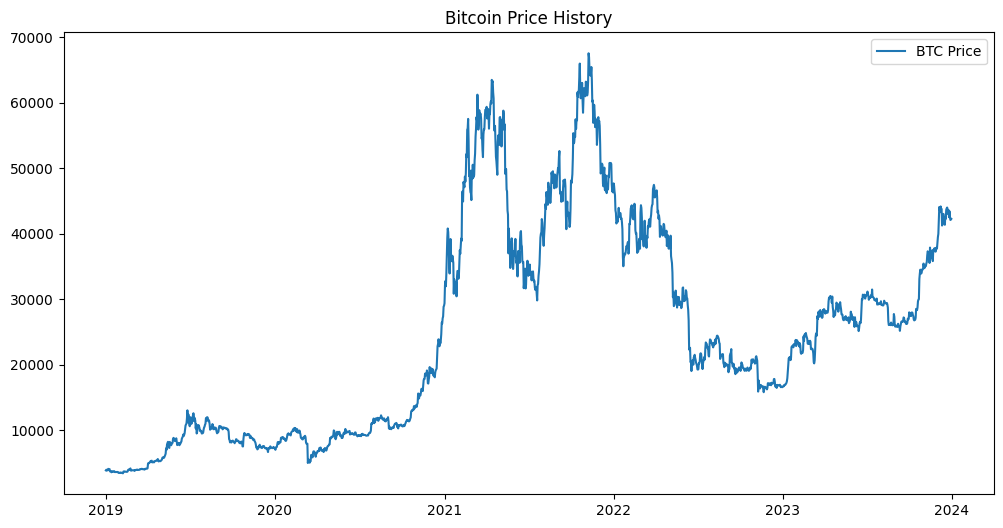

In [3]:
# 필요 라이브러리 설치 (최초 1회)
# !pip install yfinance xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn

# 1. 데이터 다운로드 (최근 5년간의 비트코인 데이터)
df = yf.download('BTC-USD', start='2019-01-01', end='2024-01-01')
data = df[['Close']].values
print(f"Data Shape: {data.shape}")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 데이터 시각화
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='BTC Price')
plt.title('Bitcoin Price History')
plt.legend()
plt.show()

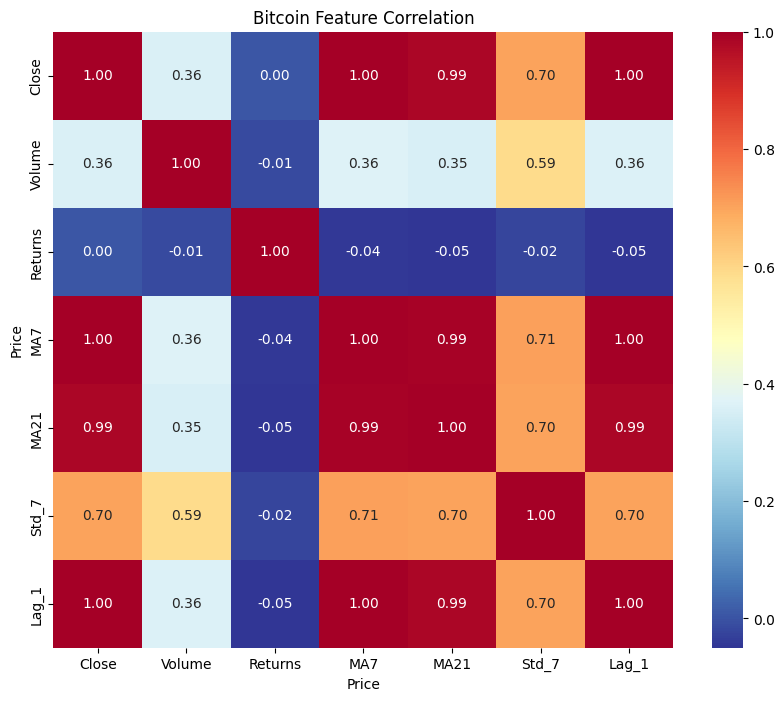

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 분석을 위한 데이터프레임 복사
analysis_df = df.copy()

# 2. 기술적 지표 계산 (이름을 단순하게 통일합니다)
analysis_df['Returns'] = analysis_df['Close'].pct_change()          # 수익률
analysis_df['MA7'] = analysis_df['Close'].rolling(window=7).mean()   # 7일 이동평균
analysis_df['MA21'] = analysis_df['Close'].rolling(window=21).mean() # 21일 이동평균
analysis_df['Std_7'] = analysis_df['Close'].rolling(window=7).std()  # 7일 변동성
analysis_df['Lag_1'] = analysis_df['Close'].shift(1)                # 전날 종가

# 결측치 제거
analysis_df.dropna(inplace=True)

# 3. 상관관계 히트맵 시각화
plt.figure(figsize=(10, 8))
# 분석에 사용할 주요 컬럼들만 선택
plot_cols = ['Close', 'Volume', 'Returns', 'MA7', 'MA21', 'Std_7', 'Lag_1']
sns.heatmap(analysis_df[plot_cols].corr(), annot=True, cmap='RdYlBu_r', fmt=".2f")
plt.title('Bitcoin Feature Correlation')
plt.show()

### 정규화 및 나누기

`yfinance`에 내장된 비트코인 데이터를 사용합니다.
이 데이터는 **2019년 ~ 2024년**까지 **비트코인 시세**를 기록한 것입니다.


In [5]:
# 데이터 정규화 (Min-Max Scaling) - 특히 RNN/LSTM에 필수적입니다.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 10
X, y = create_sequences(scaled_data, WINDOW_SIZE)

# Train/Test Split (시계열이므로 Shuffle 금지!)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (1452, 10, 1), Test set: (364, 10, 1)


### 머신러닝 알고리즘(RandomForest, XGBoost) 학습

랜덤포레스트: 설명여러 개의 결정 트리(Tree)를 독립적으로 학습시켜 평균을 내는 Bagging 방식. 이상치에 강함.

XGBoost: 이전 트리의 오차를 보완하며 순차적으로 학습하는 Boosting 방식. 성능이 매우 뛰어나며 정형 데이터의 최강자.

In [6]:
# 데이터 Flatten (Samples, Window*Features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 2. Random Forest 학습
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_flat, y_train.ravel())
rf_pred = rf_model.predict(X_test_flat)

# 3. XGBoost 학습
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05)
xgb_model.fit(X_train_flat, y_train.ravel())
xgb_pred = xgb_model.predict(X_test_flat)

print("ML Models Training Complete!")

ML Models Training Complete!


### 딥러닝 알고리즘(간단한 RNN, LSTM) 학습

RNN: 정보를 순환시켜 과거의 기억을 전달하지만, 시퀀스가 길어지면 초기 정보를 잊어버리는 Gradient Vanishing 문제가 있음.

LSTM: 'Gate' 구조(Input, Forget, Output)를 추가하여 어떤 정보를 기억하고 지울지 스스로 결정. 장기 의존성 해결.

In [9]:
# PyTorch Tensor 변환
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)

class TimeSeriesModel(nn.Module):
    def __init__(self, model_type):
        super().__init__()
        if model_type == 'RNN':
            self.rnn = nn.RNN(input_size=1, hidden_size=32, batch_first=True)
        else:
            self.rnn = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :]) # 마지막 시점의 출력만 사용
        return out

# --- 1. Simple RNN 모델 학습 ---
print("Starting Simple RNN Training...")
rnn_model = TimeSeriesModel(model_type='RNN')
rnn_criterion = nn.MSELoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.01)

for epoch in range(50):
    rnn_model.train()
    outputs = rnn_model(X_train_t)
    loss = rnn_criterion(outputs, y_train_t)
    
    rnn_optimizer.zero_grad()
    loss.backward()
    rnn_optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'RNN Epoch [{epoch+1}/50], Loss: {loss.item():.4f}')

# RNN 예측
rnn_model.eval()
rnn_pred = rnn_model(X_test_t).detach().numpy()


# --- 2. LSTM 모델 학습 ---
print("\nStarting LSTM Training...")
lstm_model = TimeSeriesModel(model_type='LSTM')
lstm_criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.01)

for epoch in range(50):
    lstm_model.train()
    outputs = lstm_model(X_train_t)
    loss = lstm_criterion(outputs, y_train_t)
    
    lstm_optimizer.zero_grad()
    loss.backward()
    lstm_optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'LSTM Epoch [{epoch+1}/50], Loss: {loss.item():.4f}')

# LSTM 예측
lstm_model.eval()
lstm_pred = lstm_model(X_test_t).detach().numpy()

print("\nDeep Learning Training Complete!")

Starting Simple RNN Training...
RNN Epoch [10/50], Loss: 0.0190
RNN Epoch [20/50], Loss: 0.0008
RNN Epoch [30/50], Loss: 0.0007
RNN Epoch [40/50], Loss: 0.0007
RNN Epoch [50/50], Loss: 0.0005

Starting LSTM Training...
LSTM Epoch [10/50], Loss: 0.0404
LSTM Epoch [20/50], Loss: 0.0080
LSTM Epoch [30/50], Loss: 0.0035
LSTM Epoch [40/50], Loss: 0.0013
LSTM Epoch [50/50], Loss: 0.0009

Deep Learning Training Complete!


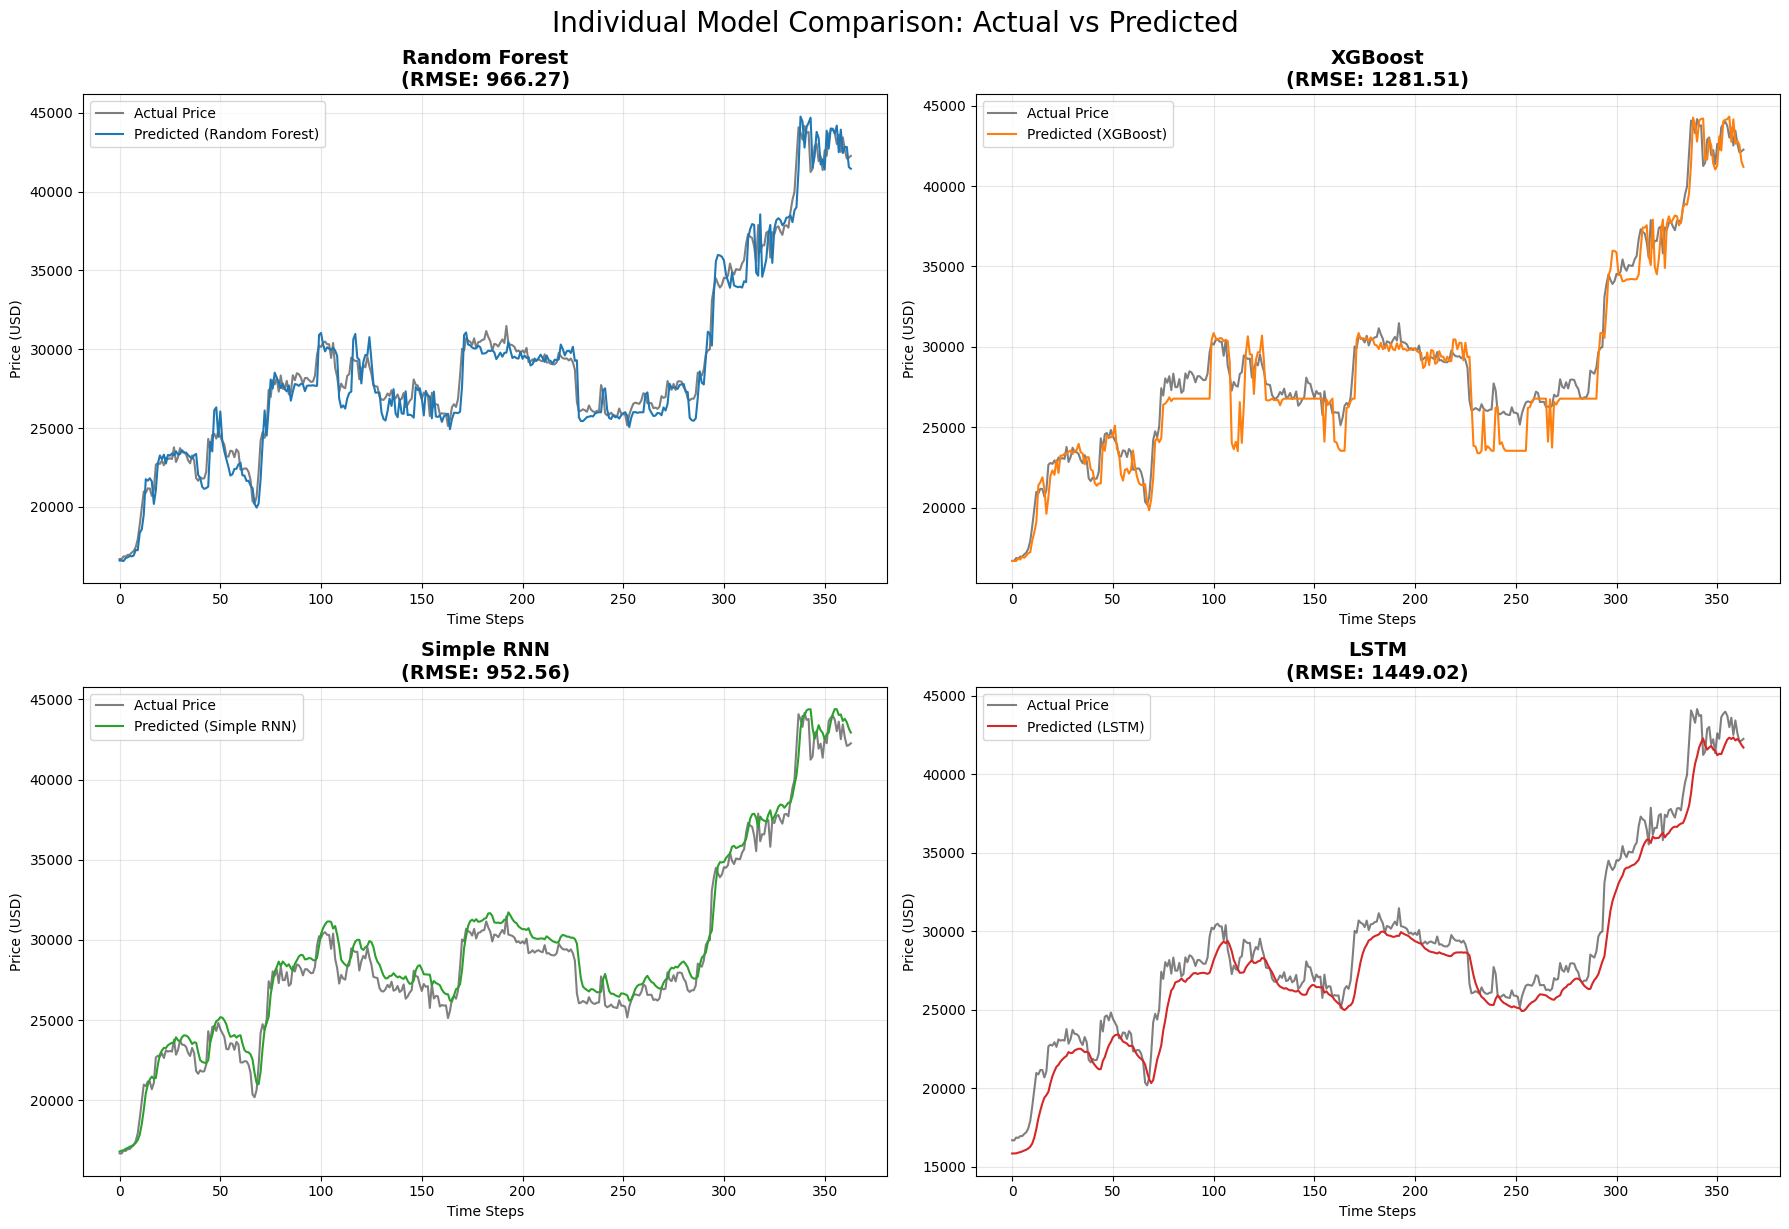


Model Name           |      RMSE Score
----------------------------------------
Random Forest        |          966.27
XGBoost              |         1281.51
Simple RNN           |          952.56
LSTM                 |         1449.02


In [11]:
import matplotlib.pyplot as plt

# 1. 시각화를 위한 설정
model_names = ['Random Forest', 'XGBoost', 'Simple RNN', 'LSTM']
model_results = [rf_res, xgb_res, rnn_res, lstm_res]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # 모델별 고유 색상

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐서 반복문 접근 용이하게 설정

for i, (name, res) in enumerate(zip(model_names, model_results)):
    # 해당 모델의 RMSE 계산
    rmse = np.sqrt(mean_squared_error(y_test_orig, res))
    
    # 각 서브플롯에 실제값과 예측값 플로팅
    axes[i].plot(y_test_orig, label='Actual Price', color='black', linewidth=1.5, alpha=0.5)
    axes[i].plot(res, label=f'Predicted ({name})', color=colors[i], linewidth=1.5)
    
    # 그래프 디테일 설정
    axes[i].set_title(f'{name}\n(RMSE: {rmse:.2f})', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Time Steps')
    axes[i].set_ylabel('Price (USD)')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

# 3. 전체 레이아웃 조정 및 출력
plt.tight_layout()
plt.suptitle('Individual Model Comparison: Actual vs Predicted', fontsize=20, y=1.02)
plt.show()

# 4. 성능 지표(RMSE) 요약 리포트 출력
print("\n" + "="*40)
print(f"{'Model Name':<20} | {'RMSE Score':>15}")
print("-" * 40)
for name, res in zip(model_names, model_results):
    rmse = np.sqrt(mean_squared_error(y_test_orig, res))
    print(f"{name:<20} | {rmse:>15.2f}")
print("="*40)

## 다변량 변수 예측

이전 위 예측에는 종가(Close)만 변수로 활용

다변량 변수 예측으로
거래량(Volume), 이동평균(MA), 변동성(Std)등 추가

In [12]:
# 1. 사용할 특징(Features) 선택
# Close(가격), Volume(거래량), MA7(추세), Std_7(변동성) 4개를 사용합니다.
feature_cols = ['Close', 'Volume', 'MA7', 'Std_7']
data_multivariate = analysis_df[feature_cols].values

# 2. 데이터 정규화 (모든 컬럼을 0~1 사이로)
scaler_all = MinMaxScaler()
scaled_data_all = scaler_all.fit_transform(data_multivariate)

# 나중에 'Close' 가격만 따로 복원하기 위한 전용 스케일러 (평가용)
scaler_close = MinMaxScaler()
scaler_close.fit(analysis_df[['Close']])

print(f"선택된 피처: {feature_cols}")
print(f"데이터 형태: {scaled_data_all.shape}") # (데이터 수, 4)

선택된 피처: ['Close', 'Volume', 'MA7', 'Std_7']
데이터 형태: (1806, 4)


In [13]:
def create_multivariate_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        # X: 10일치 4개 피처 데이터 (10, 4)
        X.append(data[i:i+window_size, :]) 
        # y: 다음 날의 '종가' (첫 번째 컬럼인 Close만 타겟으로 설정)
        y.append(data[i+window_size, 0]) 
    return np.array(X), np.array(y)

WINDOW_SIZE = 10
X_multi, y_multi = create_multivariate_sequences(scaled_data_all, WINDOW_SIZE)

# Train/Test Split
train_size = int(len(X_multi) * 0.8)
X_train_m, X_test_m = X_multi[:train_size], X_multi[train_size:]
y_train_m, y_test_m = y_multi[:train_size], y_multi[train_size:]

print(f"X_train 형태: {X_train_m.shape}") # (샘플 수, 10, 4)
print(f"y_train 형태: {y_train_m.shape}") # (샘플 수,)

X_train 형태: (1436, 10, 4)
y_train 형태: (1436,)


In [16]:
# --- 1. 머신러닝용 Flatten ---
X_train_m_flat = X_train_m.reshape(X_train_m.shape[0], -1)
X_test_m_flat = X_test_m.reshape(X_test_m.shape[0], -1)

# --- 2. 딥러닝 모델 (Input Size = 4) ---
class MultiTimeSeriesModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        # input_size가 1에서 4로 변경되었습니다.
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=64, batch_first=True, num_layers=2)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# 모델 생성 (피처가 4개이므로 input_size=4)
model_multi = MultiTimeSeriesModel(input_size=len(feature_cols))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_multi.parameters(), lr=0.001)

# PyTorch용 텐서 변환
X_train_mt = torch.FloatTensor(X_train_m)
y_train_mt = torch.FloatTensor(y_train_m).view(-1, 1)

In [17]:
# 1. 머신러닝 모델 (RF, XGB) 학습 및 예측
print("Training ML Models...")
# Random Forest
rf_multi = RandomForestRegressor(n_estimators=100, random_state=42)
rf_multi.fit(X_train_m_flat, y_train_m)
rf_pred_m = rf_multi.predict(X_test_m_flat)

# XGBoost
xgb_multi = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_multi.fit(X_train_m_flat, y_train_m)
xgb_pred_m = xgb_multi.predict(X_test_m_flat)

# 2. 딥러닝 모델 학습 함수 정의 (RNN & LSTM)
def train_model(model_type):
    model = MultiTimeSeriesModel(input_size=len(feature_cols))
    # 내부 레이어를 RNN으로 교체 (기본은 LSTM)
    if model_type == 'RNN':
        model.lstm = nn.RNN(input_size=len(feature_cols), hidden_size=64, batch_first=True, num_layers=2)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    model.train()
    for epoch in range(100):
        outputs = model(X_train_mt)
        loss = criterion(outputs, y_train_mt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

print("Training Deep Learning Models...")
rnn_net = train_model('RNN')
lstm_net = train_model('LSTM')

# 3. 딥러닝 예측값 생성
rnn_net.eval()
lstm_net.eval()
with torch.no_grad():
    X_test_mt = torch.FloatTensor(X_test_m)
    rnn_pred_m = rnn_net(X_test_mt).numpy()
    lstm_pred_m = lstm_net(X_test_mt).numpy()

# 4. 결과 복원 (Inverse Transform) - 이 과정이 있어야 그래프가 그려집니다.
# y_test_actual은 실제 정답지입니다.
y_test_actual = scaler_close.inverse_transform(y_test_m.reshape(-1, 1))
rf_res_m = scaler_close.inverse_transform(rf_pred_m.reshape(-1, 1))
xgb_res_m = scaler_close.inverse_transform(xgb_pred_m.reshape(-1, 1))
rnn_res_m = scaler_close.inverse_transform(rnn_pred_m)
lstm_res_m = scaler_close.inverse_transform(lstm_pred_m)

print("모든 모델 학습 및 결과 복원 완료!")

Training ML Models...
Training Deep Learning Models...
모든 모델 학습 및 결과 복원 완료!


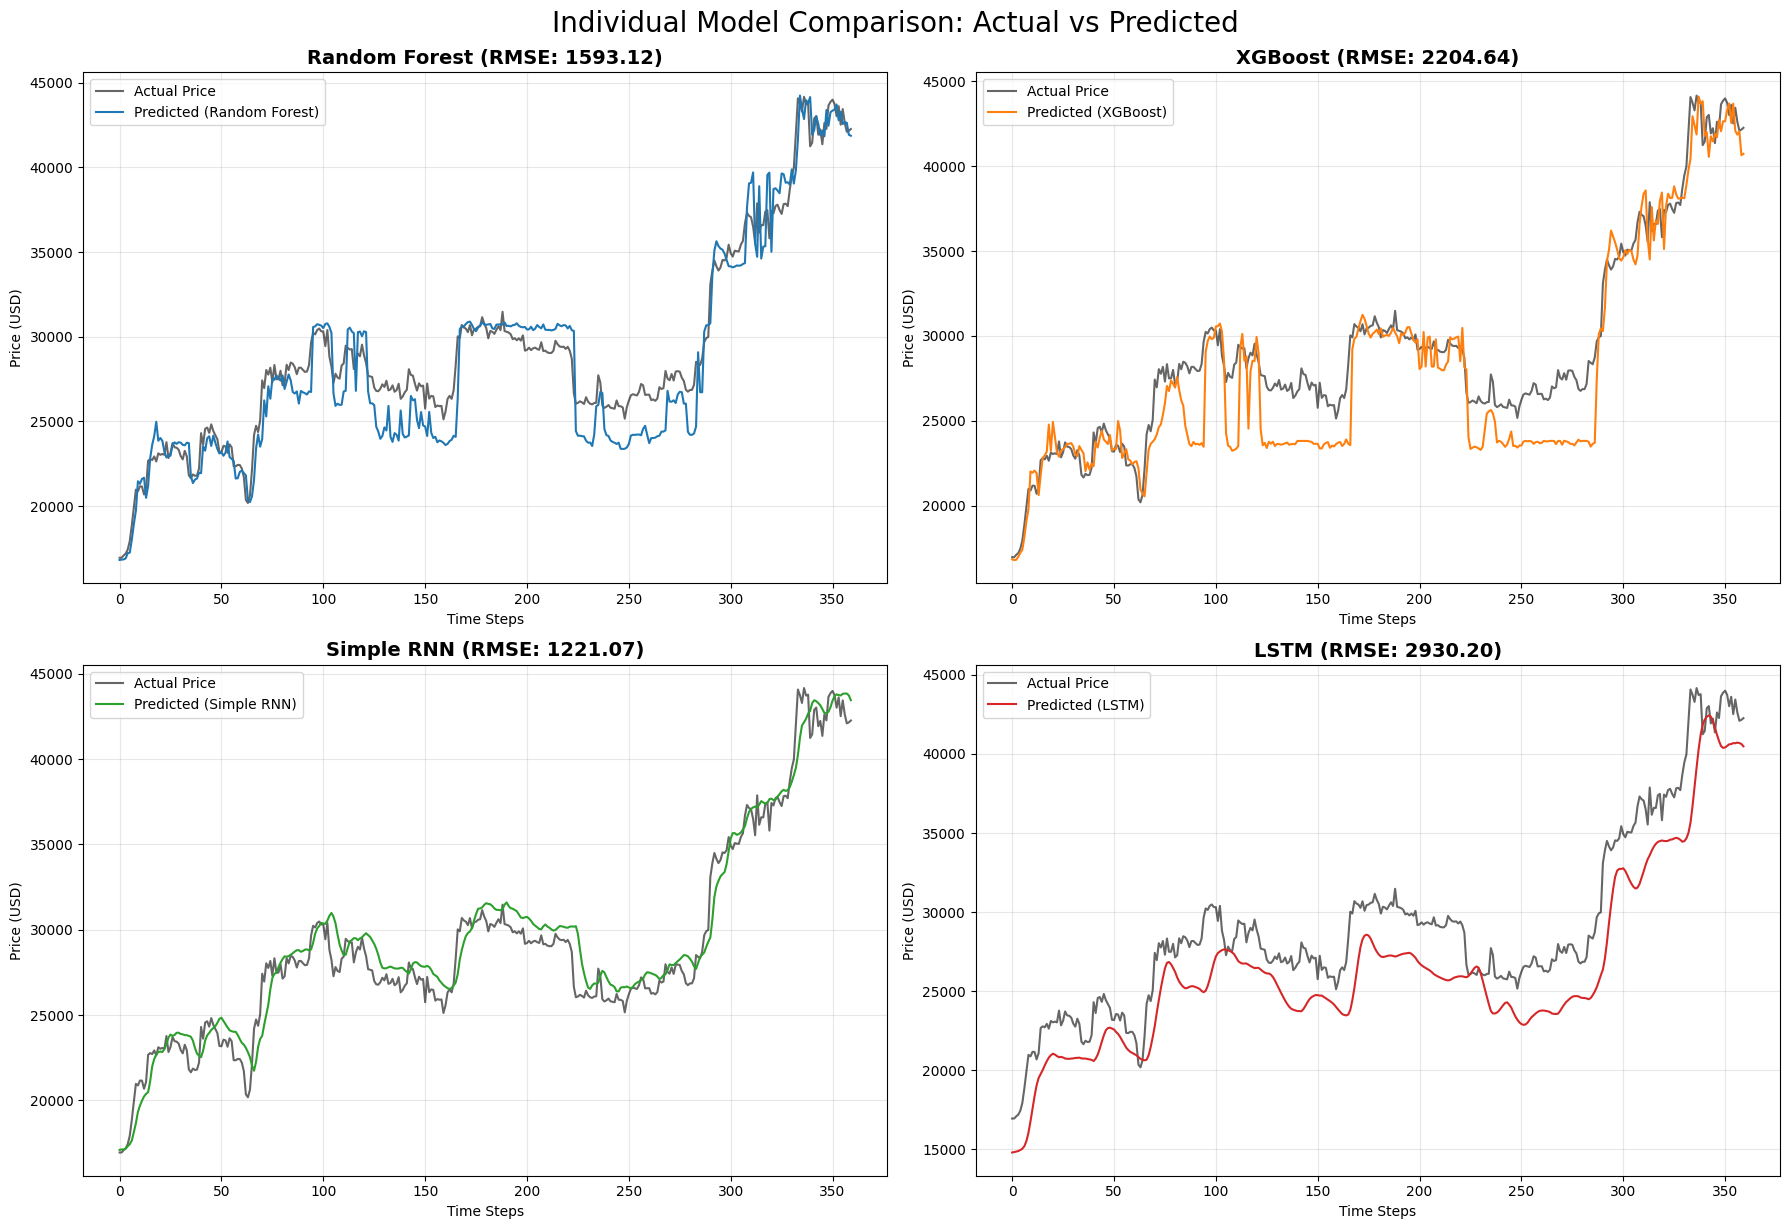

------------------------------
Model           | RMSE      
------------------------------
Random Forest   |    1593.12
XGBoost         |    2204.64
Simple RNN      |    1221.07
LSTM            |    2930.20
------------------------------


In [18]:
import matplotlib.pyplot as plt

# 모델 이름과 결과 데이터 매핑
model_names = ['Random Forest', 'XGBoost', 'Simple RNN', 'LSTM']
model_results = [rf_res_m, xgb_res_m, rnn_res_m, lstm_res_m]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # 각 모델별 고유 색상

# 2x2 서브플롯 생성
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten() # 2차원 배열을 1차원으로 평탄화하여 반복문 사용 용이하게 함

for i, (name, res) in enumerate(zip(model_names, model_results)):
    # RMSE 계산
    rmse = np.sqrt(mean_squared_error(y_test_actual, res))
    
    # 그래프 그리기
    axes[i].plot(y_test_actual, label='Actual Price', color='black', linewidth=1.5, alpha=0.6)
    axes[i].plot(res, label=f'Predicted ({name})', color=colors[i], linewidth=1.5)
    
    # 그래프 설정
    axes[i].set_title(f'{name} (RMSE: {rmse:.2f})', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Time Steps')
    axes[i].set_ylabel('Price (USD)')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

# 전체 레이아웃 조정 및 출력
plt.tight_layout()
plt.suptitle('Individual Model Comparison: Actual vs Predicted', fontsize=20, y=1.02)
plt.show()

# 최종 RMSE 리포트 (기존과 동일)
print("-" * 30)
print(f"{'Model':<15} | {'RMSE':<10}")
print("-" * 30)
for name, res in zip(model_names, model_results):
    rmse = np.sqrt(mean_squared_error(y_test_actual, res))
    print(f"{name:<15} | {rmse:>10.2f}")
print("-" * 30)